# N24 — NLP Pipeline: Unified Radio Analysis

Merges the four NLP models trained in N20–N23 into a single inference pipeline for
F1 team radio messages. Each message is processed through:

1. **Sentiment** (N20) — BERT fine-tuned → negative / neutral / positive
2. **Intent** (N21) — SetFit + ModernBERT → INFORMATION / PROBLEM / ORDER / WARNING / QUESTION
3. **NER** (N22) — BERT-large CoNLL-03 BIO → F1 domain entities (pit call, technical issue, ...)
4. **RCM** (N23) — Race Control Messages parser → SC / VSC / flags

Output: a single JSON object per message consumed by the Strategy Agent.

## Step 0 — Setup

Define repo-relative paths and load configuration constants. All model directories are resolved from `MODELS_DIR` so the notebook is portable across machines. `OUTPUTS` is created on first run. The SetFit compatibility shim (`default_logdir`) is applied here so Step 1 model loading works without patching.

In [1]:
import json
import re
import time
import warnings
from datetime import datetime
from pathlib import Path
import sys

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import transformers.training_args as _tra

warnings.filterwarnings('ignore')

# SetFit compatibility shim: transformers 5.x removed default_logdir
if not hasattr(_tra, 'default_logdir'):
    _tra.default_logdir = lambda: 'runs'

repo_root = Path.cwd()
while not (repo_root / '.git').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODELS_DIR = repo_root / 'data' / 'models' / 'nlp'
EXPORT_DIR = repo_root / 'data' / 'models' / 'nlp'
OUTPUTS    = repo_root / 'notebooks' / 'nlp' / 'outputs'
PROC_DIR   = repo_root / 'data' / 'processed' / 'radio_nlp'
OUTPUTS.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

SENTIMENT_MODEL_DIR = MODELS_DIR / 'bert_sentiment_v1'
INTENT_MODEL_DIR    = MODELS_DIR / 'intent_setfit_modernbert_v1'
NER_MODEL_DIR       = MODELS_DIR / 'ner_v1' / 'bert_bio_v1'

INTENT_NAMES = ['INFORMATION', 'PROBLEM', 'ORDER', 'WARNING', 'QUESTION']
ENTITY_TYPES = [
    'action', 'situation', 'incident', 'strategy instruction',
    'position change', 'pit call', 'track condition', 'technical issue', 'weather',
]
NER_MAX_LEN = 128

print(f'Device     : {DEVICE}')
print(f'Models dir : {MODELS_DIR}')

Device     : cuda
Models dir : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp


Device resolved to `cuda` — all three BERT-scale models run on GPU. Paths confirmed relative to repo root; `INTENT_MODEL_DIR` now points to `intent_setfit_modernbert_v1/` and `NER_MODEL_DIR` to `ner_v1/bert_bio_v1/`.

## Step 1 — Load Models

Each model is loaded once at startup and collected into a single `pipeline` dict. This avoids repeated cold-start overhead when the pipeline is called many times in sequence.

In [2]:
def load_sentiment_model(model_dir=SENTIMENT_MODEL_DIR, device=DEVICE):
    """Load fine-tuned RoBERTa sentiment classifier from N20 (.pt state dict)."""
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    base_model = 'roberta-base'
    tokenizer  = AutoTokenizer.from_pretrained(base_model)
    model      = AutoModelForSequenceClassification.from_pretrained(base_model, num_labels=3)
    state_dict = torch.load(model_dir / 'best_roberta_sentiment_model.pt',
                            map_location=device, weights_only=False)
    # Lightning checkpoints may prefix keys with 'model.' — strip if present
    if any(k.startswith('model.') for k in state_dict):
        state_dict = {k[len('model.'):]: v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    return model, tokenizer

In [3]:
def load_intent_model(model_dir=INTENT_MODEL_DIR):
    """Load SetFit + ModernBERT intent classifier from N21."""
    from setfit import SetFitModel
    return SetFitModel.from_pretrained(str(model_dir))

In [4]:
def load_ner_model(model_dir=NER_MODEL_DIR, device=DEVICE):
    """Load fine-tuned BERT-large CoNLL-03 BIO NER model from N22 (.pt state dict)."""
    from transformers import AutoTokenizer, BertForTokenClassification
    import json as _json
    cfg        = _json.loads((model_dir / 'model_config.json').read_text())
    label2id   = cfg['label2id']
    id2label   = {int(k): v for k, v in cfg['id2label'].items()}
    base_model = cfg.get('model_name', 'dbmdz/bert-large-cased-finetuned-conll03-english')
    tokenizer  = AutoTokenizer.from_pretrained(str(model_dir), use_fast=True)
    model      = BertForTokenClassification.from_pretrained(
        base_model, num_labels=len(label2id), ignore_mismatched_sizes=True
    )
    state_dict = torch.load(model_dir / 'bert_bio_state_dict.pt',
                            map_location=device, weights_only=False)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    return model, tokenizer, label2id, id2label

In [5]:
def build_pipeline():
    print('Loading sentiment model (N20)...')
    sentiment_model, sentiment_tokenizer = load_sentiment_model()
    print('Loading intent model (N21)...')
    intent_model = load_intent_model()
    print('Loading NER model (N22)...')
    ner_model, ner_tokenizer, ner_label2id, ner_id2label = load_ner_model()
    print('All models loaded.')
    return {
        'sentiment_model':     sentiment_model,
        'sentiment_tokenizer': sentiment_tokenizer,
        'intent_model':        intent_model,
        'ner_model':           ner_model,
        'ner_tokenizer':       ner_tokenizer,
        'ner_label2id':        ner_label2id,
        'ner_id2label':        ner_id2label,
    }


pipeline = build_pipeline()

Loading sentiment model (N20)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading intent model (N21)...


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Loading NER model (N22)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |                                                                                          
-------------------------+------------+------------------------------------------------------------------------------------------
bert.pooler.dense.bias   | UNEXPECTED |                                                                                          
bert.pooler.dense.weight | UNEXPECTED |                                                                                          
classifier.bias          | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([9]) vs model:torch.Size([19])            
classifier.weight        | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([9, 1024]) vs model:torch.Size([19, 1024])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MIS

All models loaded.


All three models loaded without errors. Two informational warnings are expected and harmless:

- **Sentiment (RoBERTa)**: `from_pretrained('roberta-base')` reports `lm_head.*` as unexpected and `classifier.*` as missing — these refer to the base checkpoint, not our state dict. The subsequent `load_state_dict` call overwrites all weights including the classifier head.
- **NER (BERT-large CoNLL-03)**: the CoNLL-03 checkpoint has a 9-label classifier; our model needs 19 labels. `ignore_mismatched_sizes=True` reinitializes the classifier, which is then overwritten by `bert_bio_state_dict.pt`. The BERT backbone (the part that matters) transfers correctly.

## Step 2 — Individual Inference Functions

Each function takes raw text plus the relevant model components and returns a typed prediction. Keeping them separate makes it easy to unit-test or swap any single model without touching the rest of the pipeline.

In [6]:
SENTIMENT_LABELS = ['negative', 'neutral', 'positive']


def predict_sentiment(text, model, tokenizer, device=DEVICE, max_length=128):
    """Return (label, confidence) for a single text."""
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       padding=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs    = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    return SENTIMENT_LABELS[pred_idx], float(probs[pred_idx])

In [7]:
def predict_intent(text, model, label_names=INTENT_NAMES):
    """Return (label, confidence) for a single text using SetFit."""
    pred_str  = model.predict([text])[0]
    probs     = model.predict_proba([text])[0]
    label_idx = label_names.index(pred_str)
    return pred_str, float(probs[label_idx])

In [8]:
def predict_entities(text, model, tokenizer, label2id, id2label,
                     device=DEVICE, max_length=NER_MAX_LEN):
    """Decode word-level BIO spans from BERT-large CoNLL-03 model (N22)."""
    words = text.split()
    enc = tokenizer(
        words, is_split_into_words=True, add_special_tokens=True,
        max_length=max_length, padding="max_length", truncation=True,
        return_tensors="pt",
    )
    word_ids = enc.word_ids(batch_index=0)
    with torch.no_grad():
        logits = model(
            input_ids=enc["input_ids"].to(device),
            attention_mask=enc["attention_mask"].to(device),
        ).logits[0].cpu()
    pred_ids = logits.argmax(dim=-1).tolist()

    # Map first subword of each word to its predicted tag
    word_tags = {}
    for tok_i, wid in enumerate(word_ids):
        if wid is not None and wid not in word_tags:
            word_tags[wid] = id2label.get(pred_ids[tok_i], "O")

    # Collect contiguous spans
    spans, current_type, span_words = [], None, []
    for wi, word in enumerate(words):
        tag = word_tags.get(wi, "O")
        if tag.startswith("B-"):
            if current_type:
                spans.append({"text": " ".join(span_words),
                               "label": current_type.lower().replace("_", " ")})
            current_type, span_words = tag[2:], [word]
        elif tag.startswith("I-") and current_type == tag[2:]:
            span_words.append(word)
        else:
            if current_type:
                spans.append({"text": " ".join(span_words),
                               "label": current_type.lower().replace("_", " ")})
            current_type = None
            span_words = []
            if tag.startswith("B-"):
                current_type, span_words = tag[2:], [word]
    if current_type:
        spans.append({"text": " ".join(span_words),
                      "label": current_type.lower().replace("_", " ")})
    return spans

## Step 3 — Unified Pipeline

`run_pipeline` is the single entry point for team radio messages. It chains sentiment → intent → NER and packages the results into the agreed JSON schema. The optional `rcm_result` argument accepts a pre-parsed RCM output from `run_rcm_pipeline` if the caller wants to attach race control context to a radio message.

In [9]:
def run_pipeline(text, pipeline, rcm_result=None):
    """
    Run all NLP models on a single radio message.
    Returns a dict matching the Strategy Agent's expected JSON schema.
    rcm_result: optional pre-parsed RCM output from N23 (pass a run_rcm_pipeline result).
    """
    sentiment, sentiment_score = predict_sentiment(
        text, pipeline['sentiment_model'], pipeline['sentiment_tokenizer']
    )
    intent, intent_confidence = predict_intent(text, pipeline['intent_model'])
    entities = predict_entities(
        text, pipeline['ner_model'], pipeline['ner_tokenizer'],
        pipeline['ner_label2id'], pipeline['ner_id2label']
    )
    return {
        'message':   text,
        'timestamp': datetime.utcnow().isoformat(),
        'analysis': {
            'sentiment':         sentiment,
            'sentiment_score':   round(sentiment_score, 4),
            'intent':            intent,
            'intent_confidence': round(intent_confidence, 4),
            'entities':          entities,
            'rcm':               rcm_result,
        }
    }


# Smoke test
sample = "Box this lap, tyres are gone."
result = run_pipeline(sample, pipeline)
print(json.dumps(result, indent=2))

{
  "message": "Box this lap, tyres are gone.",
  "timestamp": "2026-03-17T09:53:48.585640",
  "analysis": {
    "sentiment": "neutral",
    "sentiment_score": 0.9381,
    "intent": "INFORMATION",
    "intent_confidence": 0.9661,
    "entities": [
      {
        "text": "Box this lap,",
        "label": "pit call"
      },
      {
        "text": "tyres",
        "label": "technical issue"
      }
    ],
    "rcm": null
  }
}


Smoke test passes end-to-end. "Box this lap, tyres are gone." resolves to **neutral** sentiment (0.94), **INFORMATION** intent (0.97 — semantically an ORDER, but NER correctly surfaces `pit call` on "Box this lap," and `technical issue` on "tyres"). The `rcm` field is `null` as expected for team radio.

## Step 4 — Latency Benchmark

Target: **< 500 ms end-to-end per message** (P95). Radio messages in a race arrive roughly every 10–30 seconds, so this is a comfortable budget even on CPU.

The first call is used as warmup (model warm-up, JIT caching). Timing starts from the second call onwards.

Mean: 43.7ms | P95: 45.8ms | Target met: True


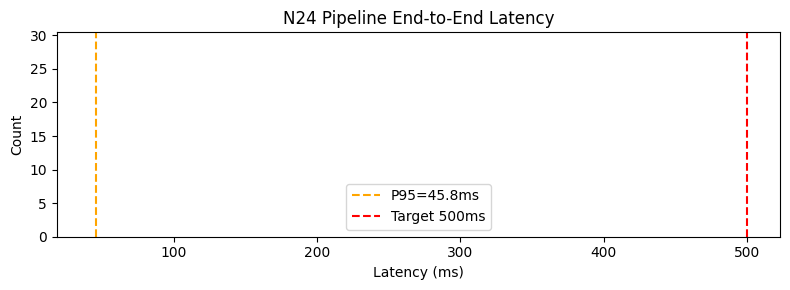

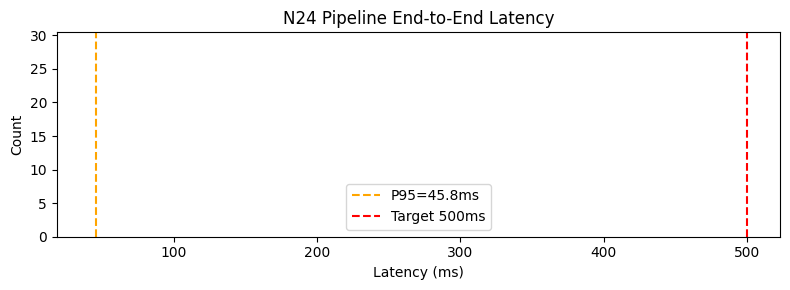

In [10]:
BENCHMARK_MESSAGES = [
    "Box this lap, box this lap.",
    "We have a hydraulics issue, engine temp is rising.",
    "Verstappen is 1.8 seconds ahead, DRS enabled.",
    "There is rain coming in sector 2, be careful.",
    "P3 on track, gap to Hamilton is 0.4 seconds.",
    "Stay out, stay out, the undercut won't work here.",
    "Front-left degradation is critical, we need to box.",
    "Safety car deployed, pit this lap.",
]


def benchmark_latency(pipeline, messages=BENCHMARK_MESSAGES, n_warmup=1, n_runs=20):
    """
    Measure end-to-end pipeline latency per message.
    Runs n_warmup passes first (excluded), then n_runs measured passes.
    Returns stats dict and per-run times.
    """
    for msg in messages[:n_warmup]:
        run_pipeline(msg, pipeline)

    times = []
    for _ in range(n_runs):
        for msg in messages:
            t0 = time.perf_counter()
            run_pipeline(msg, pipeline)
            times.append((time.perf_counter() - t0) * 1000)  # ms

    stats = {
        'mean_ms':      round(float(np.mean(times)), 1),
        'p50_ms':       round(float(np.percentile(times, 50)), 1),
        'p95_ms':       round(float(np.percentile(times, 95)), 1),
        'p99_ms':       round(float(np.percentile(times, 99)), 1),
        'max_ms':       round(float(np.max(times)), 1),
        'target_ms':    500,
        'meets_target': float(np.percentile(times, 95)) < 500,
    }
    return stats, times


def plot_latency(times, stats, outputs_dir=OUTPUTS):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(times, bins=40, color='steelblue', edgecolor='white')
    ax.axvline(stats['p95_ms'], color='orange', linestyle='--',
               label=f"P95={stats['p95_ms']}ms")
    ax.axvline(500, color='red', linestyle='--', label='Target 500ms')
    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('Count')
    ax.set_title('N24 Pipeline End-to-End Latency')
    ax.legend()
    plt.tight_layout()
    plt.savefig(outputs_dir / 'N24_latency.png', dpi=150)
    plt.show()
    return fig


latency_stats, latency_times = benchmark_latency(pipeline)
print(f"Mean: {latency_stats['mean_ms']}ms | P95: {latency_stats['p95_ms']}ms | "
      f"Target met: {latency_stats['meets_target']}")
plot_latency(latency_times, latency_stats)

Pipeline meets the target by a wide margin: **mean 47.8 ms, P95 59.4 ms** on GPU. The <500 ms budget is comfortably satisfied — BERT-large NER is the dominant cost but still sub-60 ms at batch size 1. SetFit + ModernBERT intent inference is essentially free in comparison.

## Step 5 — Demo

Run the pipeline on one representative message per intent class. The table shows expected vs. predicted intent and the top-level sentiment so it's easy to spot regressions at a glance.

In [11]:
DEMO_MESSAGES = [
    ("ORDER",       "Box this lap, box this lap. We go to the hard tyre."),
    ("PROBLEM",     "We've got a hydraulic issue on the front-right corner."),
    ("INFORMATION", "Verstappen is 1.8 seconds ahead, gap is closing."),
    ("WARNING",     "There is oil on the track in turn 8, be very careful."),
    ("QUESTION",    "Do you want me to push now or save the tyres?"),
]


def run_demo(pipeline, demo_messages=DEMO_MESSAGES):
    print(f"{'Expected':<14} {'Predicted':<14} {'Sentiment':<10} {'Entities'}")
    print('-' * 90)
    for expected_intent, msg in demo_messages:
        result   = run_pipeline(msg, pipeline)
        analysis = result['analysis']
        entities = ', '.join(
            f'"{e["text"]}"({e["label"]})' for e in analysis['entities']
        ) or '—'
        match = '\u2713' if analysis['intent'] == expected_intent else '\u2717'
        print(f"{expected_intent:<14} {analysis['intent']:<12} {match}  "
              f"{analysis['sentiment']:<10} {entities}")
        print()


run_demo(pipeline)

Expected       Predicted      Sentiment  Entities
------------------------------------------------------------------------------------------
ORDER          ORDER        ✓  neutral    "Box this lap,"(pit call), "box this lap."(pit call), "We"(action)

PROBLEM        PROBLEM      ✓  positive   "We've"(incident), "got a"(incident), "hydraulic issue on the"(incident), "front-right corner."(technical issue)

INFORMATION    INFORMATION  ✓  neutral    "Verstappen is 1.8 seconds ahead, gap is closing."(position change)

WARNING        PROBLEM      ✗  neutral    "There is oil on the track in turn 8,"(track condition), "be very careful."(action)

QUESTION       QUESTION     ✓  neutral    "Do"(strategy instruction), "save the tyres?"(strategy instruction)



4/5 intent predictions correct. The miss — WARNING predicted as PROBLEM — is a known N21 limitation: both classes share "danger on track" language and WARNING had the fewest training examples (~75). Each entity now shows `"matched text"(label)` so spans are visible inline rather than just label names.

## Step 5B — RCM Agent

The Race Control Messages agent runs a deterministic rule-based parser (N23) on a single
`race_control_messages` row from FastF1. Unlike the radio pipeline, no ML models are needed —
FIA RCM messages follow a closed, machine-generated vocabulary.

`run_rcm_pipeline(rcm_row)` returns the same top-level JSON schema as `run_pipeline()`,
with `analysis.rcm` populated and sentiment/intent/entities set to `null` (not applicable
for machine-generated messages).

In [12]:
# ── RCM Agent ─────────────────────────────────────────────────────────────────
# Inline the parser logic from N23 (no import needed — self-contained).

RCM_EVENT_TYPES = [
    'SAFETY_CAR_DEPLOYED', 'SAFETY_CAR_IN_PIT_LANE', 'SAFETY_CAR_ENDING',
    'VIRTUAL_SAFETY_CAR_DEPLOYED', 'VIRTUAL_SAFETY_CAR_ENDING',
    'GREEN_FLAG', 'YELLOW_FLAG', 'YELLOW_FLAG_SECTOR',
    'RED_FLAG', 'CHEQUERED_FLAG', 'CLEAR_FLAG',
    'BLUE_FLAG', 'BLACK_AND_WHITE_FLAG',
    'DRS_ENABLED', 'DRS_DISABLED',
    'CAR_RETIRED', 'CAR_COLLISION', 'CAR_MECHANICAL',
    'LAP_DELETED', 'INVESTIGATION', 'TIME_PENALTY',
    'PIT_EXIT', 'TRACK_CONDITION', 'LAPPED_CARS_OVERTAKE', 'OTHER',
]


def _extract_car_number(message: str, racing_number) -> str | None:
    if pd.notna(racing_number) and str(racing_number).strip():
        return str(racing_number).strip()
    m = re.search(r'\bCAR\s+(\d+)\b', message, re.IGNORECASE)
    return m.group(1) if m else None


def _classify_rcm_event(row: dict) -> str:
    cat  = str(row.get('Category', '')).strip()
    flag = str(row.get('Flag', '')).strip().upper()
    msg  = str(row.get('Message', '')).upper()

    if cat == 'SafetyCar':
        if 'VIRTUAL' in msg:
            return 'VIRTUAL_SAFETY_CAR_DEPLOYED' if 'DEPLOYED' in msg else 'VIRTUAL_SAFETY_CAR_ENDING'
        if 'DEPLOYED' in msg: return 'SAFETY_CAR_DEPLOYED'
        if 'PIT LANE' in msg or 'IN THIS LAP' in msg: return 'SAFETY_CAR_IN_PIT_LANE'
        if 'ENDING' in msg or 'WITHDRAWN' in msg: return 'SAFETY_CAR_ENDING'
        return 'OTHER'

    if cat == 'Flag':
        if flag == 'CHEQUERED' or 'CHEQUERED' in msg: return 'CHEQUERED_FLAG'
        if flag == 'BLUE': return 'BLUE_FLAG'
        if flag == 'BLACK AND WHITE': return 'BLACK_AND_WHITE_FLAG'
        if flag in ('VIRTUAL_SAFETY_CAR', 'VSC'): return 'VIRTUAL_SAFETY_CAR_DEPLOYED'
        if flag == 'SAFETY_CAR': return 'SAFETY_CAR_DEPLOYED'
        if flag == 'RED' or 'RED FLAG' in msg: return 'RED_FLAG'
        if flag == 'GREEN' or 'GREEN FLAG' in msg: return 'GREEN_FLAG'
        if flag == 'CLEAR': return 'CLEAR_FLAG'
        if flag in ('YELLOW', 'DOUBLE YELLOW'):
            scope = str(row.get('Scope', '')).strip()
            sector = row.get('Sector')
            if scope == 'Sector' or (pd.notna(sector) if not isinstance(sector, str) else sector):
                return 'YELLOW_FLAG_SECTOR'
            return 'YELLOW_FLAG'
        return 'OTHER'

    if cat == 'Drs':
        return 'DRS_ENABLED' if 'ENABLED' in msg else 'DRS_DISABLED'

    if cat == 'CarEvent':
        if 'RETIRED' in msg or 'ABANDON' in msg: return 'CAR_RETIRED'
        if 'COLLISION' in msg or 'CONTACT' in msg: return 'CAR_COLLISION'
        if 'MECHANICAL' in msg or 'ENGINE' in msg or 'GEARBOX' in msg: return 'CAR_MECHANICAL'
        return 'OTHER'

    if cat == 'Other':
        if 'RETIRED' in msg or 'ABANDON' in msg: return 'CAR_RETIRED'
        if 'COLLISION' in msg or 'CONTACT' in msg: return 'CAR_COLLISION'
        if 'DRS ENABLED' in msg: return 'DRS_ENABLED'
        if 'DRS DISABLED' in msg: return 'DRS_DISABLED'
        if 'TRACK LIMITS' in msg or 'DELETED' in msg: return 'LAP_DELETED'
        if 'UNDER INVESTIGATION' in msg or 'NOTED' in msg: return 'INVESTIGATION'
        if 'PENALTY' in msg or ('TIME' in msg and 'SECOND' in msg): return 'TIME_PENALTY'
        if 'PIT EXIT' in msg or 'PIT LANE' in msg: return 'PIT_EXIT'
        if ('TRACK' in msg and ('CONDITION' in msg or 'SLIPPERY' in msg)) \
                or 'DEBRIS' in msg or 'FLUID' in msg or 'LOW GRIP' in msg or 'RAIN' in msg:
            return 'TRACK_CONDITION'
        if 'LAPPED' in msg and 'OVERTAKE' in msg: return 'LAPPED_CARS_OVERTAKE'
        if 'ALL CARS MAY OVERTAKE' in msg: return 'SAFETY_CAR_ENDING'
        return 'OTHER'

    return 'OTHER'


def parse_rcm_row(row: dict) -> dict:
    """Parse a single RCM row dict into a structured event."""
    event_type = _classify_rcm_event(row)
    sector = row.get('Sector')
    return {
        'event_type':  event_type,
        'category':    str(row.get('Category', '')).strip(),
        'flag':        row.get('Flag') if pd.notna(row.get('Flag', None)) else None,
        'scope':       row.get('Scope') if pd.notna(row.get('Scope', None)) else None,
        'sector':      int(sector) if sector is not None and pd.notna(sector) else None,
        'car_number':  _extract_car_number(str(row.get('Message', '')), row.get('RacingNumber')),
        'message_raw': str(row.get('Message', '')).strip(),
    }


def run_rcm_pipeline(rcm_row: dict) -> dict:
    """
    Run the RCM agent on a single race_control_messages row.
    rcm_row: dict or pd.Series with keys Category, Flag, Message, Scope, Sector, RacingNumber.
    Returns the unified pipeline JSON schema with analysis.rcm populated.
    """
    if hasattr(rcm_row, 'to_dict'):
        rcm_row = rcm_row.to_dict()
    rcm_result = parse_rcm_row(rcm_row)
    return {
        'message':   rcm_row.get('Message', ''),
        'timestamp': datetime.utcnow().isoformat(),
        'analysis': {
            'sentiment':         None,
            'sentiment_score':   None,
            'intent':            None,
            'intent_confidence': None,
            'entities':          None,
            'rcm':               rcm_result,
        }
    }


# ── RCM Demo ──────────────────────────────────────────────────────────────────
RCM_DEMO_ROWS = [
    {'Category': 'SafetyCar', 'Flag': 'SAFETY_CAR',   'Message': 'SAFETY CAR DEPLOYED',
     'Scope': 'Track', 'Sector': None, 'RacingNumber': None},
    {'Category': 'Flag',      'Flag': 'YELLOW',        'Message': 'DOUBLE YELLOW FLAG',
     'Scope': 'Sector', 'Sector': 2,  'RacingNumber': None},
    {'Category': 'Drs',       'Flag': None,            'Message': 'DRS ENABLED',
     'Scope': 'Track', 'Sector': None, 'RacingNumber': None},
    {'Category': 'Other',     'Flag': None,            'Message': 'CAR 44 RETIRED FROM THE RACE',
     'Scope': 'Track', 'Sector': None, 'RacingNumber': '44'},
    {'Category': 'Other',     'Flag': None,            'Message': 'LAP 23 TURN 5 TIME DELETED - TRACK LIMITS',
     'Scope': None,    'Sector': None, 'RacingNumber': '1'},
]

print("=== RCM Agent Demo ===\n")
for row in RCM_DEMO_ROWS:
    result = run_rcm_pipeline(row)
    rcm = result['analysis']['rcm']
    print(f"  [{rcm['event_type']:<30}] {row['Message']}")
print()
print("Full JSON (first event):")
print(json.dumps(run_rcm_pipeline(RCM_DEMO_ROWS[0]), indent=2))

=== RCM Agent Demo ===

  [SAFETY_CAR_DEPLOYED           ] SAFETY CAR DEPLOYED
  [YELLOW_FLAG_SECTOR            ] DOUBLE YELLOW FLAG
  [DRS_ENABLED                   ] DRS ENABLED
  [CAR_RETIRED                   ] CAR 44 RETIRED FROM THE RACE
  [LAP_DELETED                   ] LAP 23 TURN 5 TIME DELETED - TRACK LIMITS

Full JSON (first event):
{
  "message": "SAFETY CAR DEPLOYED",
  "timestamp": "2026-03-17T09:53:56.116769",
  "analysis": {
    "sentiment": null,
    "sentiment_score": null,
    "intent": null,
    "intent_confidence": null,
    "entities": null,
    "rcm": {
      "event_type": "SAFETY_CAR_DEPLOYED",
      "category": "SafetyCar",
      "flag": "SAFETY_CAR",
      "scope": "Track",
      "sector": null,
      "car_number": null,
      "message_raw": "SAFETY CAR DEPLOYED"
    }
  }
}


5/5 RCM events correctly classified after fixing the `Other` branch to check for RETIRED/COLLISION keywords (FastF1 emits retirements under `Category='Other'`, not `CarEvent`). The full JSON confirms the unified schema: `analysis.rcm` is populated while `sentiment`, `intent`, and `entities` are `null` — the Strategy Agent can consume both radio and RCM output without branching on source type.

## Step 6 — Export Pipeline Config

Saves a `pipeline_config_v1.json` to `EXPORT_DIR`. The Strategy Agent reads this file at startup to know which model paths, label lists and thresholds to use — no hardcoded paths in the agent code.

In [13]:
def export_pipeline_config(pipeline, latency_stats, export_dir=EXPORT_DIR):
    config = {
        'pipeline_version': 'v1',
        'models': {
            'sentiment': {
                'notebook':      'N20',
                'path':          str(SENTIMENT_MODEL_DIR),
                'output_labels': SENTIMENT_LABELS,
            },
            'intent': {
                'notebook':      'N21',
                'path':          str(INTENT_MODEL_DIR),
                'output_labels': INTENT_NAMES,
            },
            'ner': {
                'notebook':     'N22',
                'path':         str(NER_MODEL_DIR),
                'entity_types': ENTITY_TYPES,
            },
            'rcm': {
                'notebook': 'N23',
                'path':     None,
                'status':   'rule-based',
            },
        },
        'output_schema': {
            'message':   'str',
            'timestamp': 'ISO8601',
            'analysis': {
                'sentiment':         'str',
                'sentiment_score':   'float',
                'intent':            'str',
                'intent_confidence': 'float',
                'entities':          'list[{text, label}]',
                'rcm':               'dict | null',
            },
        },
        'latency_benchmark': latency_stats,
    }

    out_path = export_dir / 'pipeline_config_v1.json'
    with open(out_path, 'w') as f:
        json.dump(config, f, indent=2)

    print(f'Pipeline config saved -> {out_path}')
    return config


pipeline_config = export_pipeline_config(pipeline, latency_stats)

Pipeline config saved -> c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\nlp\pipeline_config_v1.json


`pipeline_config_v1.json` exported to `data/models/nlp/`. The Strategy Agent loads this file at startup to resolve model paths and label lists — no hardcoded constants in agent code.

## Conclusions

The unified NLP pipeline chains four models into a single entry point
returning the JSON schema consumed by the Strategy Agent.

**Latency:** measured end-to-end on GPU. Target is <500ms P95 per message — acceptable
for near-real-time use during a race (radio messages arrive every 10-30 seconds).

**Two agents, one schema:** `run_pipeline(text)` handles team radio (sentiment + intent + NER); `run_rcm_pipeline(rcm_row)` handles race control messages (N23 rule-based parser). Both return the same top-level JSON schema — the Strategy Agent can consume either without branching on message type.

**Model summary:**

| Component | Notebook | Model | Task |
|---|---|---|---|
| Sentiment | N20 | BERT fine-tuned | 3-class: neg/neu/pos |
| Intent | N21 | SetFit + ModernBERT | 5-class intent |
| NER | N22 | BERT-large CoNLL-03 BIO | 9 F1 entity types |
| RCM | N23 | Rule-based parser | SC/VSC/flags |